# 02 · Retention and label aliasing (the key finding)

In the echo scenarios (`exact_replay`, `long_range_revisit`,
`mid_range_revisit`, `partial_overlap`) a returning category re-appears
under a **fresh label id** (cifar224 echo ids are >= 100) rather than its
original one. `Long_Range_Retention` -- the source block's accuracy at the
final checkpoint -- reads this as catastrophic forgetting: it collapses at
the echo task. But the model hasn't forgotten the category. It has split
its prediction mass between the original id and the new one: **source +
echo accuracy sums back to roughly the pre-echo accuracy.** That's label
aliasing, not forgetting.

Same-id revisits (`cumulative_drift`'s anchors) don't have this failure
mode -- there's no second id to split mass into, and retention there is
*better* than the disjoint baseline, not worse.


In [1]:
import sys; sys.path.insert(0, '../..')
from core import loader, viz
viz.set_style()
BATCH = next(b for b in loader.discover_batches('../..') if b.name == 'b01_cifar224_simplecil_vitb16')
df = loader.load_per_task(BATCH)
print(BATCH.name, '|', len(df), 'per-task rows |',
      df[['method','scenario','seed']].drop_duplicates().shape[0], 'runs')

b01_cifar224_simplecil_vitb16 | 1512 per-task rows | 21 runs


In [2]:
SCENARIO_ORDER = [
    'disjoint_baseline', 'distribution_shift', 'cumulative_drift',
    'exact_replay', 'partial_overlap', 'mid_range_revisit', 'long_range_revisit',
]
SCENARIO_LABELS = {s: s.replace('_', ' ') for s in SCENARIO_ORDER}

In [3]:
import numpy as np, pandas as pd
from core.metrics_ext import category_level_retention
r_matrices = loader.load_r_matrices(BATCH)

In [4]:
# source_row: which R-matrix row holds the class block whose identity gets
# echoed later. echo_row: which row holds the echo's fresh label id (the
# last row, for every scenario that has one). Verified against
# clover/training/trainer.py's r_matrix.update(test_exp.task_label, ...).
ECHO_SOURCE_ROW = {
    'exact_replay': 0, 'long_range_revisit': 0,
    'mid_range_revisit': 4, 'partial_overlap': 0,
}
REFERENCE_SCENARIOS = ['disjoint_baseline', 'cumulative_drift']  # no echo id: same-id revisit or no revisit
SEEDS = (1, 2, 3)

def run_ids(scenario):
    return [f'{BATCH.dataset}__simplecil__{scenario}__seed{s}' for s in SEEDS]

mean_R = {sc: viz.mean_r_matrix(r_matrices, run_ids(sc))
          for sc in list(ECHO_SOURCE_ROW) + REFERENCE_SCENARIOS}

### The aliasing table
`before` = source-block accuracy one checkpoint before the echo; `after` = source-block accuracy at the final checkpoint (this is `Long_Range_Retention`); `echo` = the echo block's own accuracy; `sum` = after + echo, which recovers roughly `before`.

In [5]:
rows = []
for sc, src_row in ECHO_SOURCE_ROW.items():
    R = mean_R[sc]
    r = category_level_retention(R, src_row, R.shape[0] - 1)
    rows.append({'scenario': sc, **r})
for sc in REFERENCE_SCENARIOS:
    R = mean_R[sc]
    rows.append({
        'scenario': sc,
        'source_pre': R[0, R.shape[1] - 2],
        'source_post': R[0, R.shape[1] - 1],
        'echo': float('nan'), 'sum': float('nan'),
    })
table = pd.DataFrame(rows).set_index('scenario').round(3)
display(table)

,source_pre,source_post,echo,sum
scenario,,,,
exact_replay,0.765,0.306,0.464,0.770
long_range_revisit,0.765,0.405,0.374,0.779
mid_range_revisit,0.779,0.375,0.436,0.811
partial_overlap,0.768,0.564,0.626,1.190
disjoint_baseline,0.766,0.755,NaN,NaN
cumulative_drift,0.800,0.792,NaN,NaN


In [6]:
# Sanity anchors (analysis task brief, mean of 3 seeds, cifar224 SimpleCIL):
# exact_replay source-final 0.306, echo-final 0.464, sum 0.770.
er = table.loc['exact_replay']
assert abs(er['source_post'] - 0.306) < 0.01, 'source_post anchor mismatch'
assert abs(er['echo'] - 0.464) < 0.01, 'echo anchor mismatch'
assert abs(er['sum'] - 0.770) < 0.01, 'sum anchor mismatch'
print('PASS -- exact_replay matches the documented anchors')

PASS -- exact_replay matches the documented anchors

In [7]:
anchor_ret = viz.final_task_per_seed(df, 'Anchor_Retention', ['scenario'])\
    .set_index('scenario').loc['cumulative_drift', 'mean']
print(f'cumulative_drift Anchor_Retention = {anchor_ret:.3f} (anchor: 0.819)')
assert abs(anchor_ret - 0.819) < 0.01
print(f"cumulative_drift row-0 final accuracy = {table.loc['cumulative_drift', 'source_post']:.3f} "
      f"vs. disjoint_baseline {table.loc['disjoint_baseline', 'source_post']:.3f} "
      "-- same-id revisit IMPROVES retention, no aliasing to correct for.")

cumulative_drift Anchor_Retention = 0.819 (anchor: 0.819)
cumulative_drift row-0 final accuracy = 0.792 vs. disjoint_baseline 0.755 -- same-id revisit IMPROVES retention, no aliasing to correct for.


### The figure: source-block accuracy trajectory, echo drop annotated
Every echo scenario's source block tracks the same gentle decline until its echo task, where it falls off a cliff. `AIA` stays flat (0.815-0.841) across every scenario in this batch -- the model is not doing worse overall, it is just splitting one category across two ids.

saved D:\Dev\Research\clover-cl\analysis\batches\b01_cifar224_simplecil_vitb16\figures\source_block_trajectory_echo_drop.png  +  .pdf


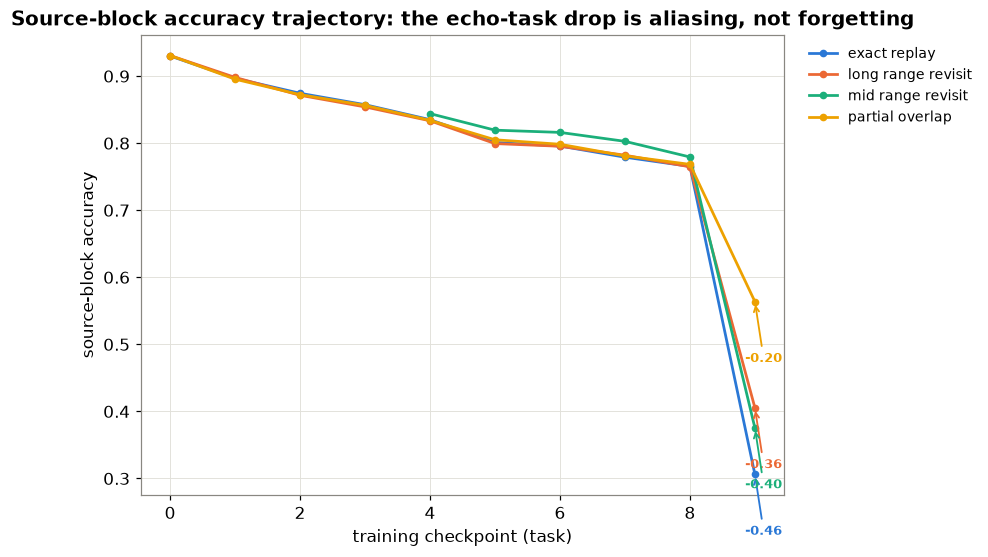

In [8]:
fig = viz.fig_source_block_trajectory(
    {sc: mean_R[sc] for sc in ECHO_SOURCE_ROW}, ECHO_SOURCE_ROW, list(ECHO_SOURCE_ROW),
    labels=SCENARIO_LABELS)
viz.save_fig(fig, BATCH.path / 'figures', 'source_block_trajectory_echo_drop')

### R-matrices: collapse-and-split vs. genuine same-id retention
`exact_replay` (left) shows the source row (row 0) fading to near-zero in its final column while a bright new row appears at the bottom -- the split. `cumulative_drift` (right) has no second row to split into: the anchor stays inside row 0 throughout and never collapses.

saved D:\Dev\Research\clover-cl\analysis\batches\b01_cifar224_simplecil_vitb16\figures\r_matrix_aliasing_vs_control.png  +  .pdf


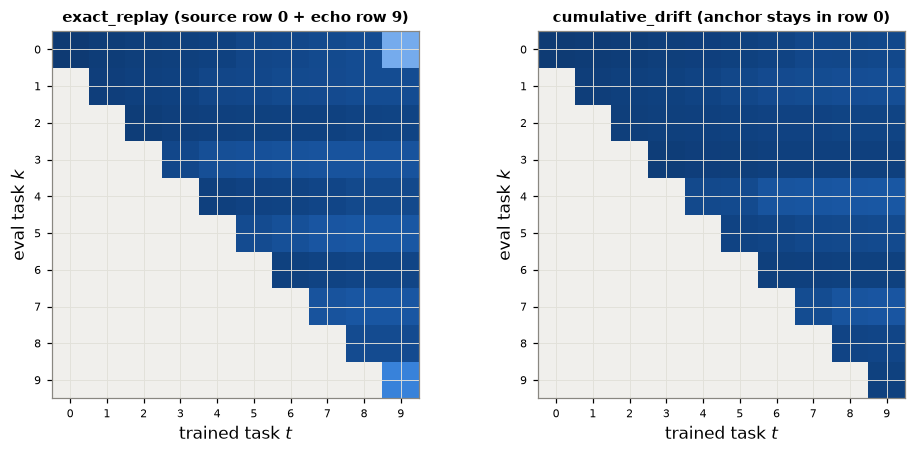

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
viz.fig_r_matrix(mean_R['exact_replay'], 'exact_replay (source row 0 + echo row 9)', ax=axes[0])
viz.fig_r_matrix(mean_R['cumulative_drift'], 'cumulative_drift (anchor stays in row 0)', ax=axes[1])
fig.tight_layout()
viz.save_fig(fig, BATCH.path / 'figures', 'r_matrix_aliasing_vs_control')

### Takeaway
`Long_Range_Retention` alone is a misleading number for the echo scenarios: read in isolation it says the model lost 40-60 points of accuracy on the original category. Read together with the echo block's own accuracy, the loss is mostly a labeling split, not a memory failure -- `category_level_retention` in `analysis/core/metrics_ext.py` is the corrective metric.